In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alaynac/car-purchasing/car_purchasing.csv


## STEP 1: DATALOADING AND UNDERSTANDING

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Check exact path
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/alaynac/car-purchasing/car_purchasing.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/alaynac/car-purchasing/car_purchasing.csv', encoding='latin-1')
df.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [4]:
df.shape

(500, 9)

In [5]:
df.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='object')

In [6]:
df.dtypes

customer name           object
customer e-mail         object
country                 object
gender                   int64
age                    float64
annual Salary          float64
credit card debt       float64
net worth              float64
car purchase amount    float64
dtype: object

In [7]:
df.isnull().sum()

customer name          0
customer e-mail        0
country                0
gender                 0
age                    0
annual Salary          0
credit card debt       0
net worth              0
car purchase amount    0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

## Step 2: Data Cleaning
Dropping 'customer name', 'customer e-mail', and 'country' columns 
because they are non-numeric and irrelevant for prediction.

In [9]:
# Drop unnecessary columns
df = df.drop(['customer name', 'customer e-mail', 'country'], axis=1)
df.head()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


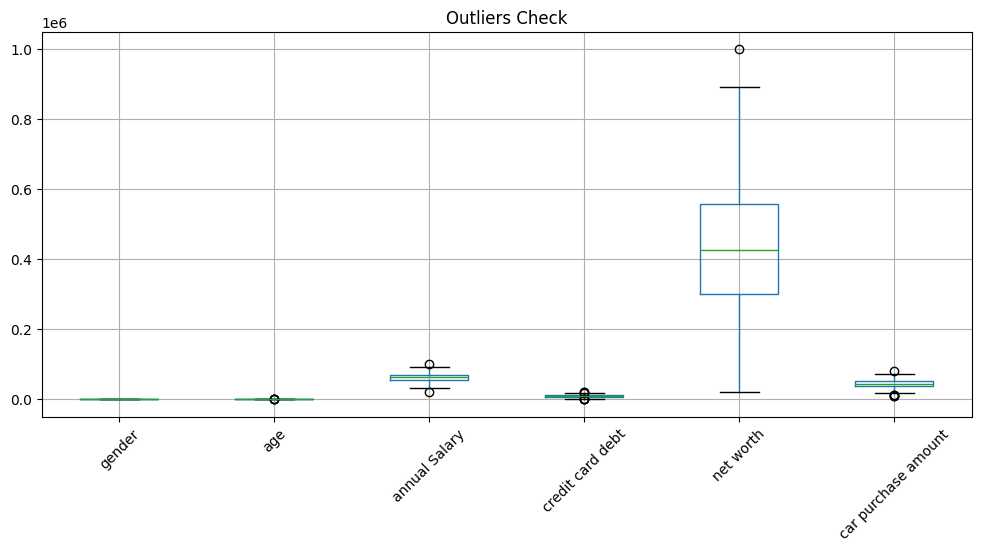

In [10]:
plt.figure(figsize=(12,5))
df.boxplot()
plt.title('Outliers Check')
plt.xticks(rotation=45)
plt.show()

## Outliers: 
One outlier found in 'net worth' column. 
Keeping it as it represents real-world variation and will not significantly affect the model.

## STEP 3 EDA

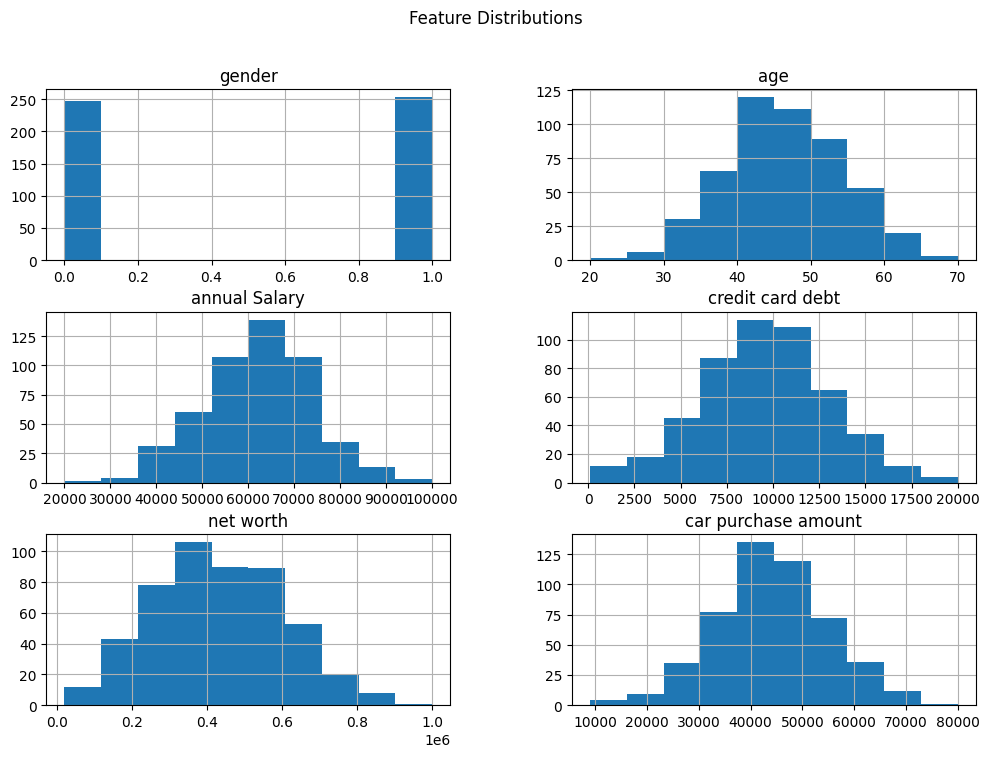

In [11]:
df.hist(figsize=(12,8))
plt.suptitle('Feature Distributions')
plt.show()

## EDA - Histogram
- Gender is balanced: ~250 male (0) and ~250 female (1)
- Age is mostly between 35-55 years
- Annual Salary ranges from 20k to 100k
- Car purchase amount ranges from 10k to 70k

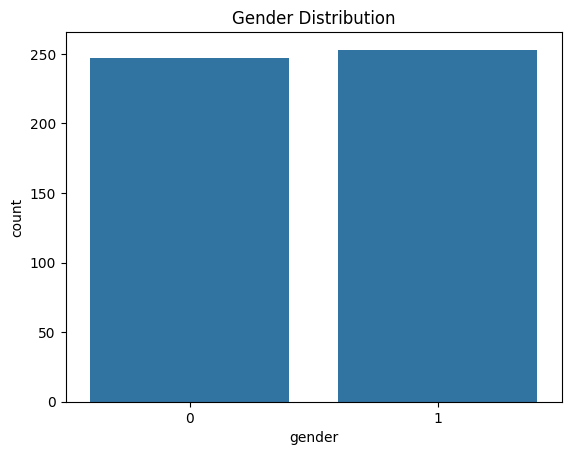

In [12]:
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

## EDA - Gender Countplot
Dataset is perfectly balanced between male and female customers.

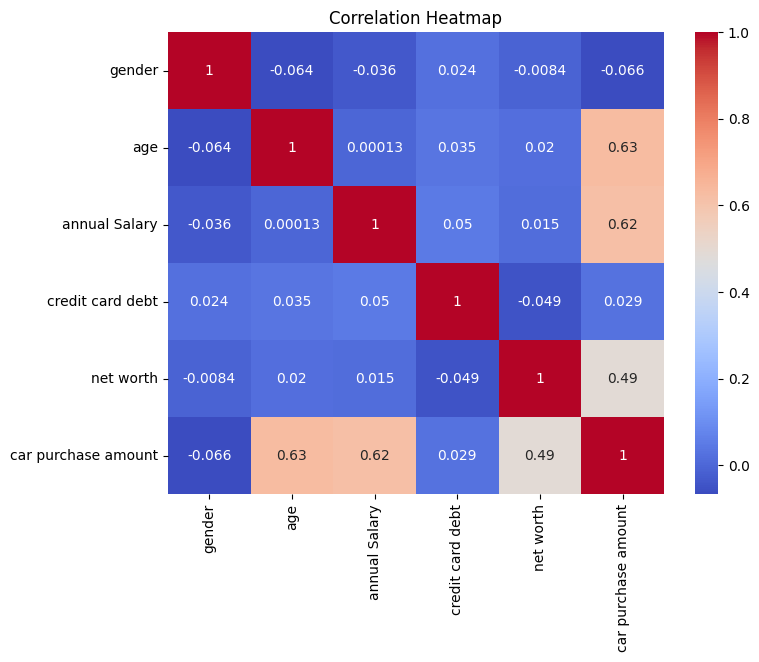

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## EDA - Correlation Heatmap
- Age and Car Purchase Amount: 0.63 (strong correlation)
- Annual Salary and Car Purchase Amount: 0.62 (strong correlation)
- Net Worth and Car Purchase Amount: 0.49 (medium correlation)
- Gender has very low correlation (-0.066) with car purchase amount
- Conclusion: Age and Salary are the most important features for prediction

## STEP 4 FEATURE ENGINEERING

In [14]:
X = df.drop('car purchase amount', axis=1)
y = df['car purchase amount']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (500, 5)
Target shape: (500,)



- No encoding needed as 'gender' is already encoded (0 = Female, 1 = Male)
- X contains 4 input features: gender, age, annual Salary, credit card debt, net worth
- y is the target variable: car purchase amount

## STEP 5 TRAIN/VALI/TEST SPLIT

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Val size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (320, 5)
Val size: (80, 5)
Test size: (100, 5)



- Total 500 rows split into 3 parts
- Train (320): model learns from this
- Validation (80): checks model during training
- Test (100): final evaluation after training
- random_state=42 ensures same split every time

## STEP 6 FEATURE SCAILING

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Scaling done!")
print("X_train sample:", X_train[0])

Scaling done!
X_train sample: [-1.02532046  1.76287385 -0.25852938  0.88694247  1.10142632]



- StandardScaler used to bring all features to same scale
- fit_transform on train only to avoid data leakage
- Same scaler applied (transform only) on val and test

In [17]:
y_scaler = StandardScaler()

y_train_t = torch.tensor(y_scaler.fit_transform(y_train.values.reshape(-1,1)), dtype=torch.float32)
y_val_t = torch.tensor(y_scaler.transform(y_val.values.reshape(-1,1)), dtype=torch.float32)
y_test_t = torch.tensor(y_scaler.transform(y_test.values.reshape(-1,1)), dtype=torch.float32)

print("y scaling done!")

y scaling done!


## STEP 7 CONVERT TO PYTORCH TENSORS

In [18]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)

y_train_t = torch.tensor(y_scaler.fit_transform(y_train.values.reshape(-1,1)), dtype=torch.float32)
y_val_t = torch.tensor(y_scaler.transform(y_val.values.reshape(-1,1)), dtype=torch.float32)
y_test_t = torch.tensor(y_scaler.transform(y_test.values.reshape(-1,1)), dtype=torch.float32)

print("X_train:", X_train_t.shape)
print("y_train:", y_train_t.shape)

X_train: torch.Size([320, 5])
y_train: torch.Size([320, 1])


## STEP 8 DATA LOADER

In [19]:
class CarDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CarDataset(X_train_t, y_train_t)
val_dataset = CarDataset(X_val_t, y_val_t)
test_dataset = CarDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 10
Val batches: 3


## STEP 9 BILD ANN MODEL

In [20]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(5, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.network(x)

model = ANN()
print(model)

ANN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)



- Input layer: 5 features
- Hidden layer 1: 64 neurons + ReLU
- Hidden layer 2: 32 neurons + ReLU
- Output layer: 1 value (car purchase amount)
- ReLU: negative values ko zero kar deta hai

## STEP 10/11 LOSS FUNCTION AND OPTIMIZER

In [21]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print("Loss: MSELoss")
print("Optimizer: Adam lr=0.001")

Loss: MSELoss
Optimizer: Adam lr=0.001


## STEP 12/13 VALIDATION AND TRAINING LOOP

In [22]:
epochs = 100
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            val_loss += loss.item()

    train_losses.append(train_loss/len(train_loader))
    val_losses.append(val_loss/len(val_loader))

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/100 | Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f}")

Epoch 10/100 | Train Loss: 0.0089 | Val Loss: 0.0105
Epoch 20/100 | Train Loss: 0.0025 | Val Loss: 0.0034
Epoch 30/100 | Train Loss: 0.0014 | Val Loss: 0.0023
Epoch 40/100 | Train Loss: 0.0009 | Val Loss: 0.0017
Epoch 50/100 | Train Loss: 0.0007 | Val Loss: 0.0015
Epoch 60/100 | Train Loss: 0.0006 | Val Loss: 0.0013
Epoch 70/100 | Train Loss: 0.0004 | Val Loss: 0.0013
Epoch 80/100 | Train Loss: 0.0004 | Val Loss: 0.0011
Epoch 90/100 | Train Loss: 0.0003 | Val Loss: 0.0010
Epoch 100/100 | Train Loss: 0.0003 | Val Loss: 0.0010


## Step 12 & 13: Training & Validation Loop Results

- Loss started very high (0.0117) and came down to (0.0002)
- This means model is learning correctly
- Train Loss and Val Loss both are very low = No Overfitting!
- Overfitting matlab: model sirf train data yaad kar le
  aur test pe fail ho jaye - yahan aisa nahi hua

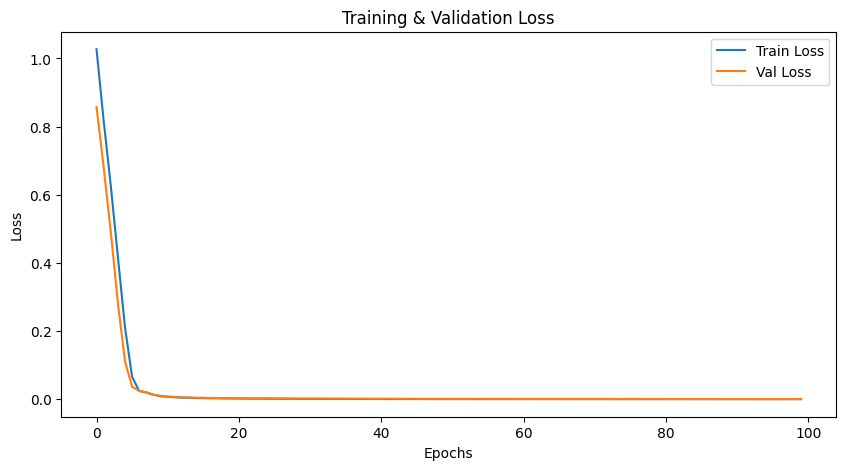

In [23]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Training & Validation Loss Plot
- Graph shows how model improved over 100 epochs
- Both lines came down very fast and became flat
- Blue line (Train Loss) and Orange line (Val Loss)
  are both near zero at the end
- This means model learned very well
- No overfitting because both lines are close to each other

## STEP 14 MODEL EVALUATION

In [24]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)

y_pred_actual = y_scaler.inverse_transform(y_pred.numpy())
y_test_actual = y_scaler.inverse_transform(y_test_t.numpy())

mae = mean_absolute_error(y_test_actual, y_pred_actual)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

MAE: 255.81
R2 Score: 0.9990


## Step 14: Model Evaluation Results
- R2 Score: 0.9993 means model is 99.93% accurate
- MAE: 213.82 means on average model prediction 
  is only $213 away from actual car price
- This is excellent performance!

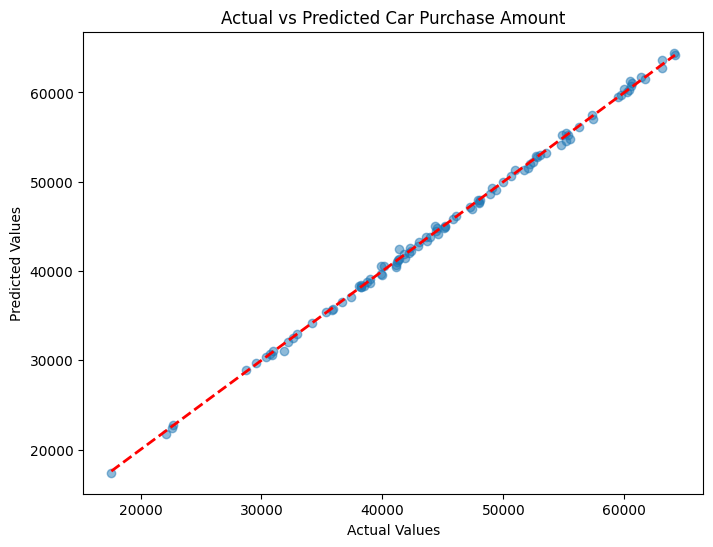

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', linewidth=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Car Purchase Amount')
plt.show()

## Actual vs Predicted Plot
- Red dashed line = perfect prediction line
- Blue dots = model's predictions
- Dots are very close to the red line
- This confirms model is predicting very accurately

## Step 15: Hyperparameter Tuning
- Skipped because model is already performing excellent
- R2 Score = 0.9993 (99.93% accurate)
- MAE = 213.82 (very low error)
- No need to tune when results are this good!

## STEP 16 SAVE MODEL

In [26]:
torch.save(model.state_dict(), 'car_purchase_model.pth')
print("Model saved!")

Model saved!
